In [687]:
# !pip install fredapi

In [688]:
from fredapi import Fred
import yfinance as yf
import pandas_datareader.data as web

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, MinMaxScaler

# !pip install pingouin
import pingouin as pg

#### Import Stock Data

In [689]:
# add as many precious metals as possible

In [690]:
### Current Tickers ###
mineral_stocks = [
    'GC=F',  # Gold
    'HG=F',  # Copper
    'PA=F',  # Palladium
    'PL=F',  # Platinum
    'SI=F',  # Silver
]

growth_stocks = [
    "NVDA",  # NVIDIA Corporation
    "MRVL",  # Marvell Technology Inc.
    "FTNT",  # Fortinet Inc.
    "AMD",   # Advanced Micro Devices, Inc.
    "CRM",   # Salesforce Inc.
    "ADBE",  # Adobe Inc.
    "ZM",    # Zoom Video Communications Inc.
    "SHOP",  # Shopify Inc.
    "SNAP",  # Snap Inc.
    "NET",   # Cloudflare, Inc.
    "TWLO",  # Twilio Inc.
    "MDB",   # MongoDB, Inc.
    "RBLX",  # Roblox Corporation
    "SNOW",  # Snowflake Inc.
    "PINS",  # Pinterest Inc.
    "TTD",   # The Trade Desk
    "DOCU",   # DocuSign, Inc.
    'SLAB'   # Silicon Laboratories Inc.
]

value_stocks = [
    "AAPL",  # Apple Inc.
    "MSFT",  # Microsoft Corporation
    "INTC",  # Intel Corporation
    "IBM",   # International Business Machines Corporation
    "ORCL",  # Oracle Corporation
    "CSCO",  # Cisco Systems, Inc.
    "HPE",   # Hewlett Packard Enterprise Co.
    "QCOM",  # Qualcomm Incorporated
    "TXN",   # Texas Instruments Incorporated
    "AVGO",  # Broadcom Inc.
    "MU",    # Micron Technology Inc.
    "LRCX",  # Lam Research Corporation
    "STX",   # Seagate Technology Holdings PLC
    "WDC",   # Western Digital Corporation
    "ADI",   # Analog Devices, Inc.
    "AMAT",  # Applied Materials, Inc.
    "MSI",   # Motorola Solutions, Inc.
    "VZ",    # Verizon Communications Inc.
    "TMUS"   # T-Mobile US, Inc.
]

In [691]:
start_date = "2020-01-01"


### Download Mineral Data ###
minerals = yf.download(mineral_stocks,start=start_date)[["Close","Volume"]]
minerals = minerals.reset_index(names='Date')
minerals = minerals.dropna()
minerals.columns = [(x[1] +' '+ x[0]).strip() for x in minerals.columns.to_list()]

### Create time stamp columns ###
minerals['Year'] = minerals.Date.dt.year
minerals['Month'] = minerals.Date.dt.month
minerals['Month Name'] = minerals.Date.dt.month_name()
minerals['Day'] = minerals.Date.dt.day



## Download Closing Price of Growth and Value Stocks in One DataFrame ###
all_stocks = growth_stocks + value_stocks
stock_data = yf.download(all_stocks, start=start_date, progress=False)['Close']
stock_data.reset_index(names='Date',inplace=True)

[*********************100%***********************]  5 of 5 completed


#### Import Federal Economic Data

In [692]:
### EFFECTIVE FEDERAL FUNDS RATE ###
api_key = '970cbbb9d211d4b85f4e294ac3ccb3ff'
fred = Fred(api_key=api_key)
effr = fred.get_series('EFFR',observation_start='2020-01-01')

effr = pd.DataFrame(effr, columns = ['EFFR']).dropna()
effr.reset_index(names='Date',inplace=True)


### U.S. Dollar Index (DXY) ###
dxy = yf.download("DX-Y.NYB", start="2020-01-01", interval="1d")
dxy.reset_index(inplace=True)
dxy['Date'] = pd.to_datetime(pd.to_datetime(dxy['Date']).dt.date)
dxy.columns = ['DXY ' + x[0]  if x[0] != 'Date' else x[0] for x in dxy.columns.to_list()]

[*********************100%***********************]  1 of 1 completed


#### Calculate daily Mineral Returns

In [693]:
minera_returns = pd.DataFrame()
data_returns['Date'] = data.Date
for col in data.columns[1:]:
    data_returns[col + ' Returns'] = data[col].pct_change(fill_method=None)

data_returns = data_returns.dropna()

We want to see if we can use predict Platinum prices from other mineral and stock data. Let's examine Platinums trend.

### Examine Platinum

In [694]:
### EXTRACT PLATINUM ###
platinum_data = minerals.filter(regex='Date|PL=F').copy()

# # calculate daily returns and 30 day volatility 
platinum_data.loc[:,'Returns'] = platinum_data['PL=F Close'].pct_change()
platinum_data.loc[:,'Volatility'] = platinum_data['Returns'].rolling(window=30,min_periods=1).std()


# # calculate log returns and log volatility
epsilon = 1e8
platinum_data.loc[:,'Log_Returns'] = np.log(platinum_data['Returns'] + epsilon)
platinum_data.loc[:,'Log_Volatility'] = np.log(platinum_data['Volatility'] + epsilon)


plat_df = platinum_data.copy()


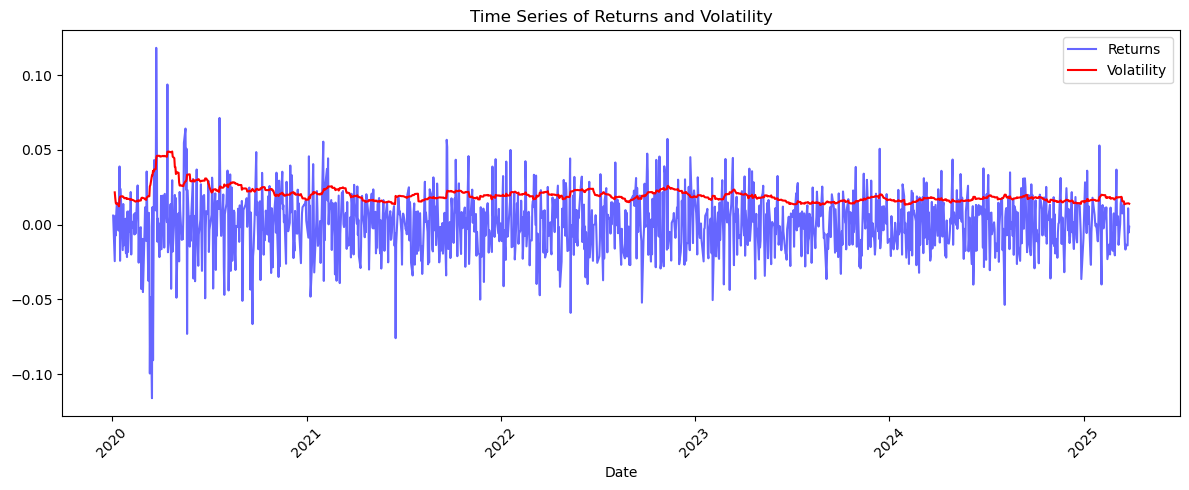

In [695]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='Returns', data=plat_df, label='Returns', color='blue',alpha=0.6)
sns.lineplot(x='Date', y='Volatility', data=plat_df, label='Volatility', color='red')


plt.xlabel('Date')
plt.ylabel('')
plt.title('Time Series of Returns and Volatility')
plt.legend()


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

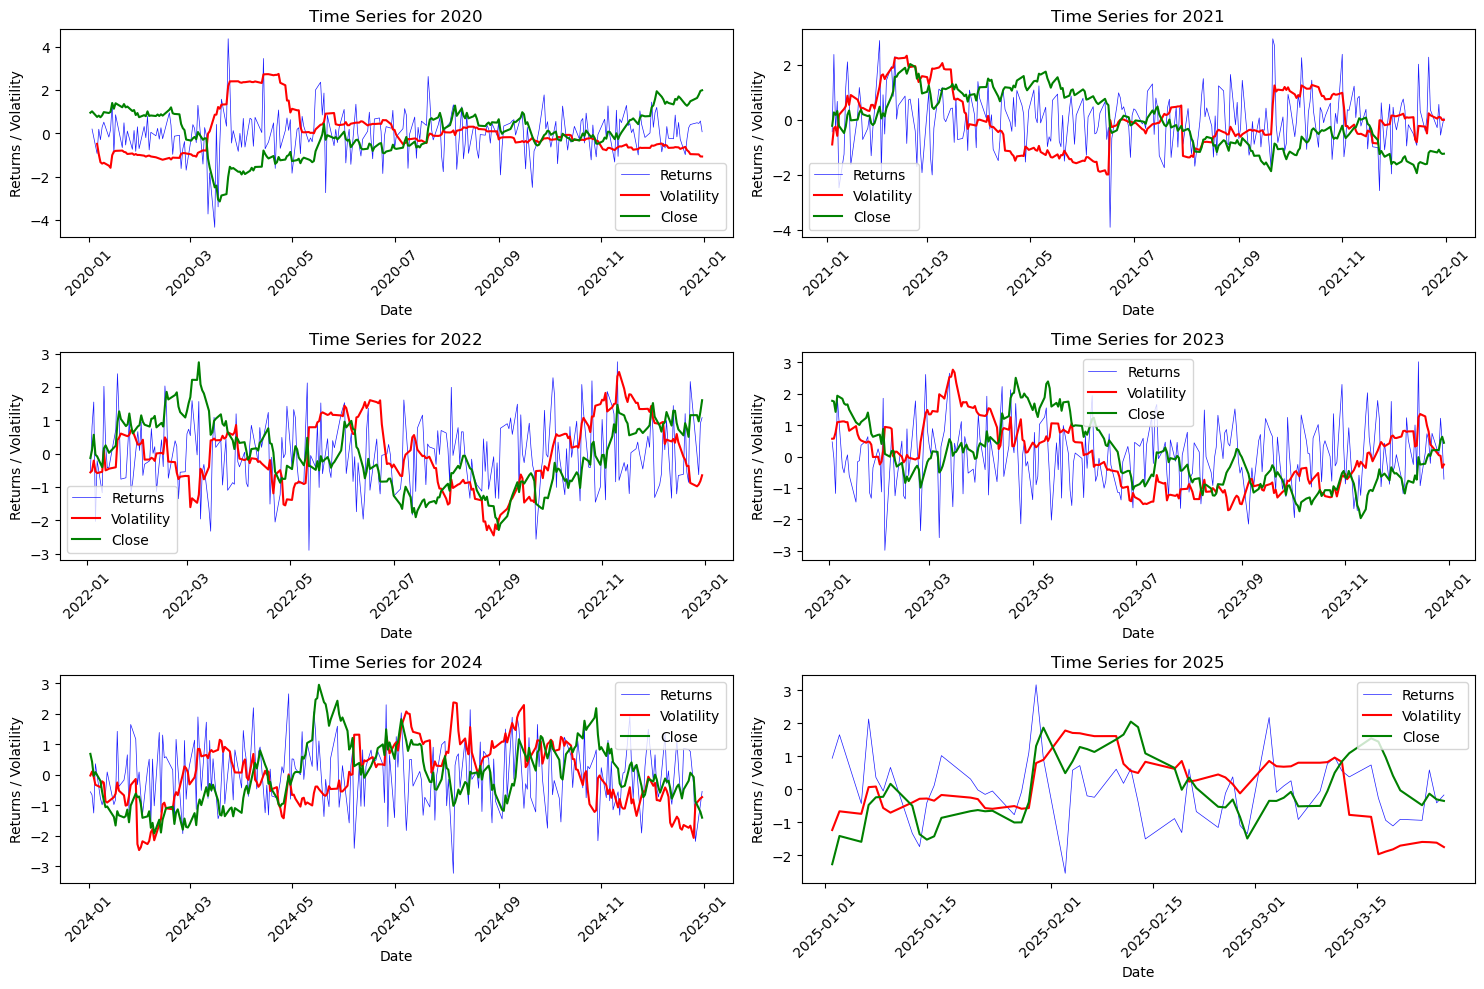

In [696]:
years = [2020, 2021, 2022, 2023, 2024, 2025]


plt.figure(figsize=(15, 10))


for i, year in enumerate(years):
   
    year_data = plat_df[plat_df['Date'].dt.year == year]
    scaler = StandardScaler()
    year_data.loc[:,["scaled_close","scaled_volatility","scaled_returns"]] = scaler.fit_transform(year_data.loc[:,["PL=F Close","Volatility","Returns"]])
    
    
    ax1 = plt.subplot(3, 2, i+1) 
    
    sns.lineplot(x='Date', y='scaled_returns', data=year_data, label='Returns', color='blue', ax=ax1,alpha=0.9, linewidth=0.5)
    sns.lineplot(x='Date', y='scaled_volatility', data=year_data, label='Volatility', color='red', ax=ax1)
    sns.lineplot(x='Date', y='scaled_close', data=year_data, label='Close', color='green', ax=ax1)
    
    
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Returns / Volatility')
    ax1.set_title(f'Time Series for {year}')
    ax1.legend(loc='best')
    ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

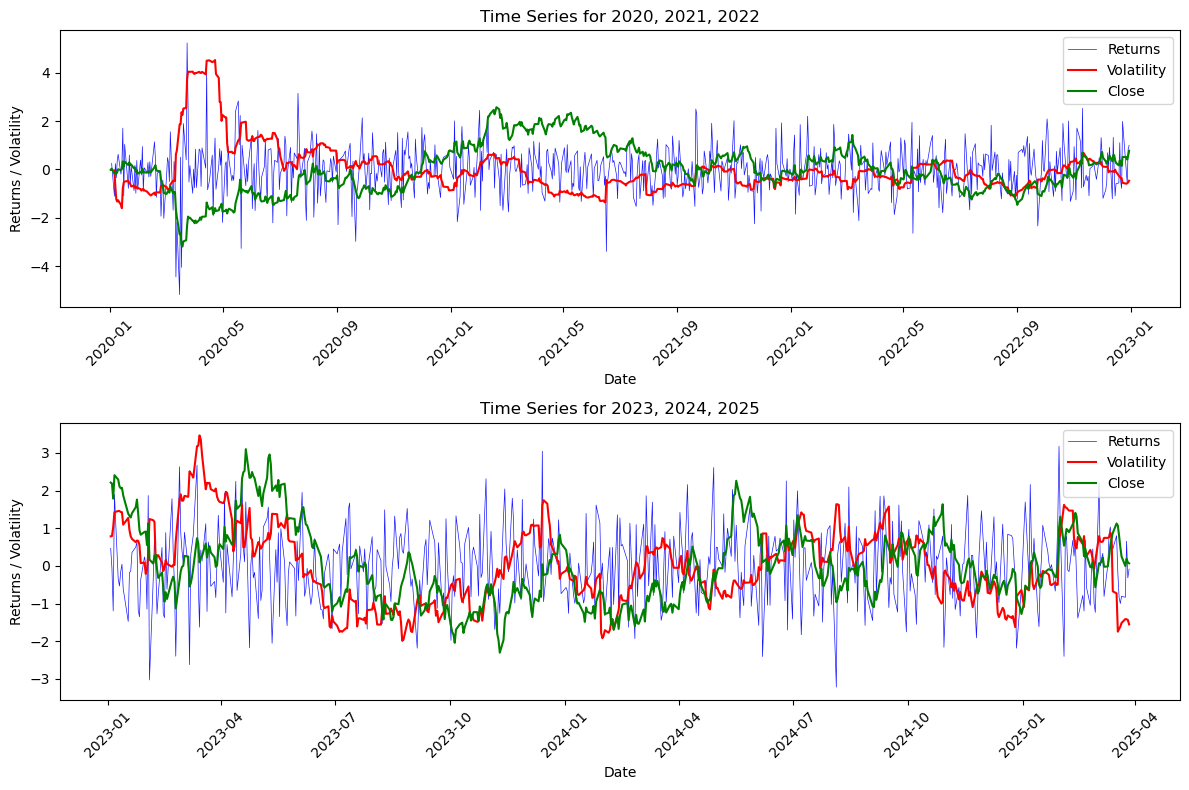

In [697]:
# Create a figure with subplots (2 rows, 1 column)
plt.figure(figsize=(15, 10))

# List of years for each plot
years_1 = [2020, 2021, 2022]
years_2 = [2023, 2024, 2025]

years = [years_1,years_2]


plt.figure(figsize=(12, 8))
for i, year in enumerate(years):
   
    year_data = plat_df[plat_df['Date'].dt.year.isin(year)]
    scaler = StandardScaler()
    year_data.loc[:,["scaled_close","scaled_volatility","scaled_returns"]] = scaler.fit_transform(year_data.loc[:,["PL=F Close","Volatility","Returns"]])
    
    
    ax1 = plt.subplot(2, 1, i+1) 
    
    sns.lineplot(x='Date', y='scaled_returns', data=year_data, label='Returns', color='blue', ax=ax1,alpha=0.9, linewidth=0.5)
    sns.lineplot(x='Date', y='scaled_volatility', data=year_data, label='Volatility', color='red', ax=ax1)
    sns.lineplot(x='Date', y='scaled_close', data=year_data, label='Close', color='green', ax=ax1)
    
    
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Returns / Volatility')
    ax1.set_title(f'Time Series for {(', ').join([str(x) for x in year])}')
    ax1.legend(loc='best')
    ax1.tick_params(axis='x', rotation=45)


plt.tight_layout()


plt.show()


#### Examine Dollar index and Effective Federal Funds Rate

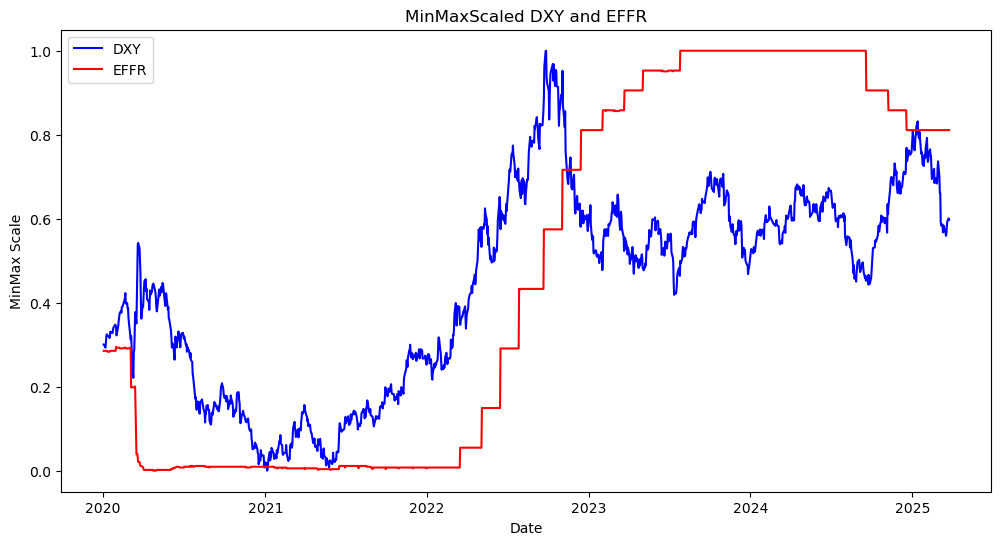

In [698]:
effr_dxy = effr.merge(dxy,on='Date',how='inner')

# scale values to visualize
scaler = MinMaxScaler()
effr_dxy.loc[:, ['dxy_scaled', 'effr_scaled']] = scaler.fit_transform(
    effr_dxy.loc[:, ['DXY Close', 'EFFR']]
)

plt.figure(figsize=(12, 6))


sns.lineplot(data=effr_dxy, x='Date', y='dxy_scaled', color='blue', label='DXY')
sns.lineplot(data=effr_dxy, x='Date', y='effr_scaled', color='red', label='EFFR')


plt.legend(loc='upper left')
plt.ylabel('MinMax Scale')
plt.title('MinMaxScaled DXY and EFFR')
plt.show()


In [699]:
## calculate log return from each closing price
minerals_log_return = minerals.filter(regex='Date|Close').copy()
minerals_log_return.iloc[:,1:] = np.log(minerals_log_return.iloc[:,1:].divide(minerals_log_return.iloc[:,1:].shift(1)))
minerals_log_return.columns = [x.replace(' Close','') + '_log_return' if x != 'Date' else x for x in minerals_log_return.columns.to_list()]

# concat original minerals with log returns
# minerals = pd.concat([minerals,minerals_log_return],axis=1)

### Normalized Mminerals by Price of First Date

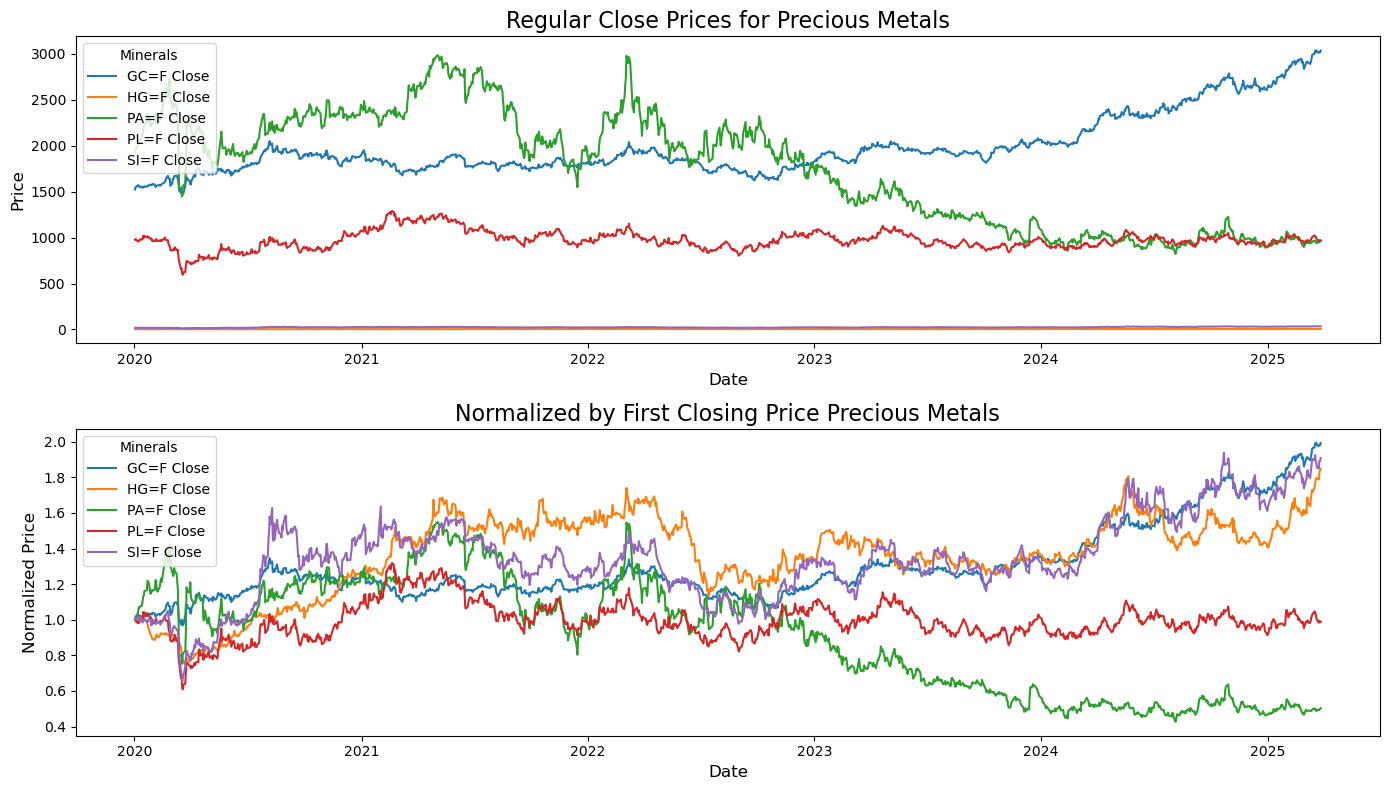

In [700]:
# Normalize the Close prices by dividing by the first value of each series
minerals_close = minerals[['Date','GC=F Close', 'HG=F Close', 'PA=F Close', 'PL=F Close', 'SI=F Close']].copy()

# Normalize each column by dividing by its first value
normalized_minerals = minerals_close.copy()
normalized_minerals.iloc[:,1:] = normalized_minerals.iloc[:,1:] / normalized_minerals.iloc[:,1:].iloc[0]
normalized_minerals_melt = pd.melt(normalized_minerals,id_vars=['Date'],var_name='Ticker',value_name='Normalized Close')


minerals_melt = pd.melt(minerals_close,id_vars=['Date'],var_name='Ticker',value_name='Close')


# Plotting the normalized Close prices
fig, axs = plt.subplots(2,1,figsize=(14, 8))

sns.lineplot(data=minerals_melt,x='Date',y='Close',hue='Ticker',ax=axs[0])

sns.lineplot(data=normalized_minerals_melt,x='Date',y='Normalized Close',hue='Ticker',ax=axs[1])



# Adding title and labels
axs[0].set_title('Regular Close Prices for Precious Metals', fontsize=16)
axs[0].set_xlabel('Date', fontsize=12)
axs[0].set_ylabel('Price', fontsize=12)
axs[0].legend(title="Minerals", loc="upper left")

# Adding title and labels
axs[1].set_title('Normalized by First Closing Price Precious Metals', fontsize=16)
axs[1].set_xlabel('Date', fontsize=12)
axs[1].set_ylabel('Normalized Price', fontsize=12)
axs[1].legend(title="Minerals", loc="upper left")

plt.tight_layout()

# Show the plot
plt.show()


In [701]:
import seaborn.objects as so
from statsmodels.tsa.stattools import acf

## Percent Change at different Window Sizes

##### analyze how past prices relate to current prices over different time horizons.

In [702]:

# Number of lags we want to create
max_lags = 10

# List of minerals
mineral_tickers = ['GC=F Close', 'HG=F Close', 'PA=F Close', 'PL=F Close', 'SI=F Close']

lag_returns_df = pd.DataFrame()
# Create lagged returns for each mineral
for mineral in mineral_tickers:
    for lag in range(1, max_lags + 1):
        lag_returns_df[f'{mineral}_returns_lag_{lag}'] = minerals[mineral].pct_change(lag,fill_method=None)

# Display the first few rows to confirm
print(lag_returns_df.shape)
lag_returns_df.head(5)


(1317, 50)


,GC=F Close_returns_lag_1,GC=F Close_returns_lag_2,GC=F Close_returns_lag_3,GC=F Close_returns_lag_4,GC=F Close_returns_lag_5,GC=F Close_returns_lag_6,GC=F Close_returns_lag_7,GC=F Close_returns_lag_8,GC=F Close_returns_lag_9,GC=F Close_returns_lag_10,...,SI=F Close_returns_lag_1,SI=F Close_returns_lag_2,SI=F Close_returns_lag_3,SI=F Close_returns_lag_4,SI=F Close_returns_lag_5,SI=F Close_returns_lag_6,SI=F Close_returns_lag_7,SI=F Close_returns_lag_8,SI=F Close_returns_lag_9,SI=F Close_returns_lag_10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.016202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.005677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.010973,0.027353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001605,0.007292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.003576,0.014588,0.031027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.012101,0.013726,0.019481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.009161,-0.005619,0.005293,0.021581,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.012448,-0.000497,0.001107,0.006791,NaN,NaN,NaN,NaN,NaN,NaN


### Correlation between Closing Price and Lagged Returns

In [703]:
# Calculate correlations between original price and lagged returns  - different window sizes of percent changes
correlations = {}

for mineral in mineral_tickers:
    for lag in range(1, max_lags + 1):
        lag_column = f'{mineral}_returns_lag_{lag}'
        correlations[f'{mineral} vs {mineral}_returns_lag_{lag}'] = pd.concat(
            [minerals[mineral],lag_returns_df[lag_column]],axis=1).dropna().corr().values[0][1]


top_correlations = sorted(correlations.items(), key=lambda x: x[1], reverse=True)[:20]

print('Top Correlations between Mineral Return and Lagged Mineral Return')
for pair, corr in top_correlations:
    print(f'{pair}: {corr:.2f}')


Top Correlations between Mineral Return and Lagged Mineral Return
PL=F Close vs PL=F Close_returns_lag_10: 0.26
PL=F Close vs PL=F Close_returns_lag_9: 0.25
PL=F Close vs PL=F Close_returns_lag_8: 0.24
PL=F Close vs PL=F Close_returns_lag_7: 0.23
PL=F Close vs PL=F Close_returns_lag_6: 0.22
GC=F Close vs GC=F Close_returns_lag_10: 0.21
PL=F Close vs PL=F Close_returns_lag_5: 0.20
GC=F Close vs GC=F Close_returns_lag_9: 0.20
GC=F Close vs GC=F Close_returns_lag_8: 0.19
PL=F Close vs PL=F Close_returns_lag_4: 0.18
SI=F Close vs SI=F Close_returns_lag_10: 0.18
GC=F Close vs GC=F Close_returns_lag_7: 0.17
PA=F Close vs PA=F Close_returns_lag_10: 0.17
SI=F Close vs SI=F Close_returns_lag_9: 0.17
PA=F Close vs PA=F Close_returns_lag_9: 0.16
PL=F Close vs PL=F Close_returns_lag_3: 0.16
SI=F Close vs SI=F Close_returns_lag_8: 0.16
GC=F Close vs GC=F Close_returns_lag_6: 0.16
PA=F Close vs PA=F Close_returns_lag_8: 0.16
PA=F Close vs PA=F Close_returns_lag_7: 0.15


In [704]:
# Create daily percent change and volatility columns
minerals_close_copy = minerals_close.copy()
for mineral in mineral_tickers:
    minerals_close_copy[f'{mineral}_daily_pct_change'] = minerals_close_copy[mineral].pct_change(fill_method=None)
    minerals_close_copy[f'{mineral} Volatility'] = minerals_close_copy[mineral].rolling(window=21,min_periods=1).std()

In [705]:
cross_correlations = {}
for i, mineral in enumerate(mineral_tickers):
    for other_mineral in mineral_tickers[i+1:]:
        if mineral != other_mineral:
            
            metal1 = minerals_close_copy[f'{mineral}_daily_pct_change']
            metal2 = minerals_close_copy[f'{other_mineral}_daily_pct_change']

            both_metals = pd.concat([metal1,metal2],axis=1).dropna().corr().iloc[0,1].round(4)

            col_name = f'{mineral}_daily_pct_change vs {other_mineral}_daily_pct_change'
            cross_correlations[col_name] = both_metals

top_cross_correlations = sorted(cross_correlations.items(), key=lambda x: x[1], reverse=True)[:]

print('Top Correlations between Mineral Return and Other Mineral Return')
for pair, corr in top_cross_correlations:
    print(f'{pair}: {corr:.2f}')

Top Correlations between Mineral Return and Other Mineral Return
GC=F Close_daily_pct_change vs SI=F Close_daily_pct_change: 0.78
PL=F Close_daily_pct_change vs SI=F Close_daily_pct_change: 0.64
PA=F Close_daily_pct_change vs PL=F Close_daily_pct_change: 0.58
GC=F Close_daily_pct_change vs PL=F Close_daily_pct_change: 0.54
HG=F Close_daily_pct_change vs PL=F Close_daily_pct_change: 0.46
PA=F Close_daily_pct_change vs SI=F Close_daily_pct_change: 0.46
HG=F Close_daily_pct_change vs SI=F Close_daily_pct_change: 0.41
GC=F Close_daily_pct_change vs PA=F Close_daily_pct_change: 0.39
HG=F Close_daily_pct_change vs PA=F Close_daily_pct_change: 0.38
GC=F Close_daily_pct_change vs HG=F Close_daily_pct_change: 0.31


In [706]:
lagged_cross_correlations = {}

for i, mineral in enumerate(mineral_tickers):
    for other_mineral in mineral_tickers[i+1:]: 
       if mineral != other_mineral: # different minerals
        for lag1 in range(1, 11):
            for lag2 in range(1, 11):
                if abs(lag1 - lag2) > 0:  # range between lags
                    metal1 = minerals[mineral].pct_change(lag1)
                    metal2 = minerals[other_mineral].pct_change(lag2)
                    both_metals = pd.concat([metal1, metal2], axis=1).dropna().corr().iloc[0, 1].round(6)

                
                    col_name = f'{mineral}_lag_{lag1}_daily_pct_change vs {other_mineral}_lag_{lag2}_daily_pct_change'
                    lagged_cross_correlations[col_name] = both_metals


top_lagged_cross_correlations = sorted(lagged_cross_correlations.items(), key=lambda x: x[1], reverse=True)[:20]

print('Top Correlations between Lagged Mineral Return and Lagged Mineral Return')
for pair, corr in top_lagged_cross_correlations:
    print(f'{pair}: {corr:.2f}')

Top Correlations between Lagged Mineral Return and Lagged Mineral Return
GC=F Close_lag_8_daily_pct_change vs SI=F Close_lag_7_daily_pct_change: 0.74
GC=F Close_lag_7_daily_pct_change vs SI=F Close_lag_6_daily_pct_change: 0.74
GC=F Close_lag_9_daily_pct_change vs SI=F Close_lag_8_daily_pct_change: 0.74
GC=F Close_lag_10_daily_pct_change vs SI=F Close_lag_9_daily_pct_change: 0.73
GC=F Close_lag_6_daily_pct_change vs SI=F Close_lag_5_daily_pct_change: 0.73
GC=F Close_lag_9_daily_pct_change vs SI=F Close_lag_10_daily_pct_change: 0.73
GC=F Close_lag_5_daily_pct_change vs SI=F Close_lag_6_daily_pct_change: 0.73
GC=F Close_lag_8_daily_pct_change vs SI=F Close_lag_9_daily_pct_change: 0.73
GC=F Close_lag_6_daily_pct_change vs SI=F Close_lag_7_daily_pct_change: 0.72
GC=F Close_lag_7_daily_pct_change vs SI=F Close_lag_8_daily_pct_change: 0.72
GC=F Close_lag_5_daily_pct_change vs SI=F Close_lag_4_daily_pct_change: 0.72
GC=F Close_lag_4_daily_pct_change vs SI=F Close_lag_5_daily_pct_change: 0.72
G

### All stocks log returns

In [744]:
## calculate log return from each closing price
stock_data_log_return = stock_data.copy()
stock_data_log_return.iloc[:,1:] = np.log(stock_data_log_return.iloc[:,1:].divide(stock_data_log_return.iloc[:,1:].shift(1)))
stock_data_log_return.columns = [x+'_log_return' if x != 'Date' else x for x in stock_data_log_return.columns.to_list()]

stock_data_log_return.set_index('Date',inplace=True)

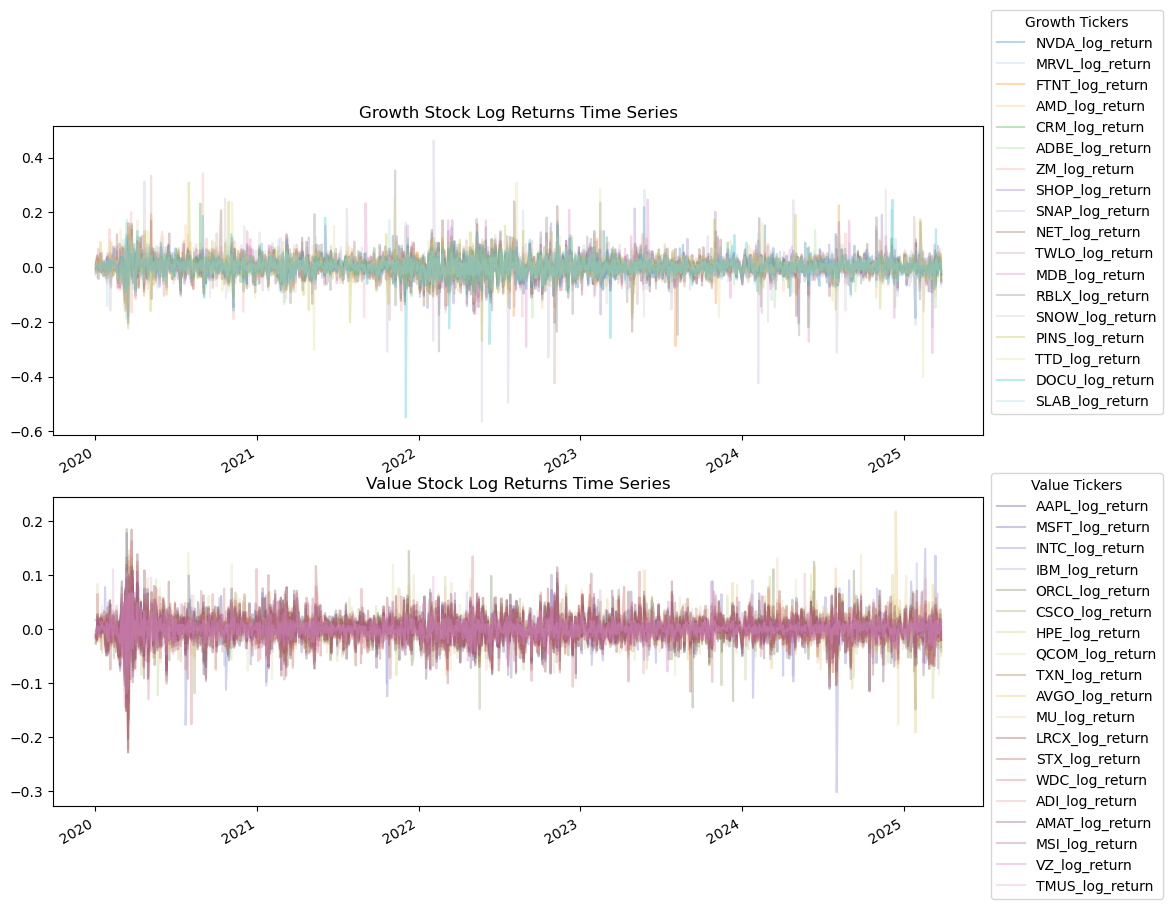

In [746]:
# Plotting the time series for each stock ticker (log returns) in the stock_returns_df

fig,axs = plt.subplots(2,1,figsize=(12,10))

stock_data_log_return.loc[:,[col+"_log_return" for col in growth_stocks]].plot(cmap='tab20',ax=axs[0],alpha=0.3)

stock_data_log_return.loc[:,[col+"_log_return" for col in value_stocks]].plot(cmap='tab20b',ax=axs[1],alpha=0.3)

axs[0].set_title('Growth Stock Log Returns Time Series')
axs[0].legend(title='Growth Tickers',loc='upper right', bbox_to_anchor=(1.2, 1.4))
axs[0].set_xlabel('')

axs[1].set_title('Value Stock Log Returns Time Series')
axs[1].legend(title='Value Tickers',loc='upper right', bbox_to_anchor=(1.2, 1.1))
axs[1].set_xlabel('')


plt.show()

In [709]:
# List of columns for the different groups
minerals_log_return_columns = minerals_log_return.columns.to_list()[1:]
minerals_volatility_columns = minerals_close_copy.filter(like='Vol').columns.to_list()
stock_log_return_columns = stock_data_log_return.columns.to_list()[1:]
minerals_close_columns = minerals_close.columns[1:].to_list()


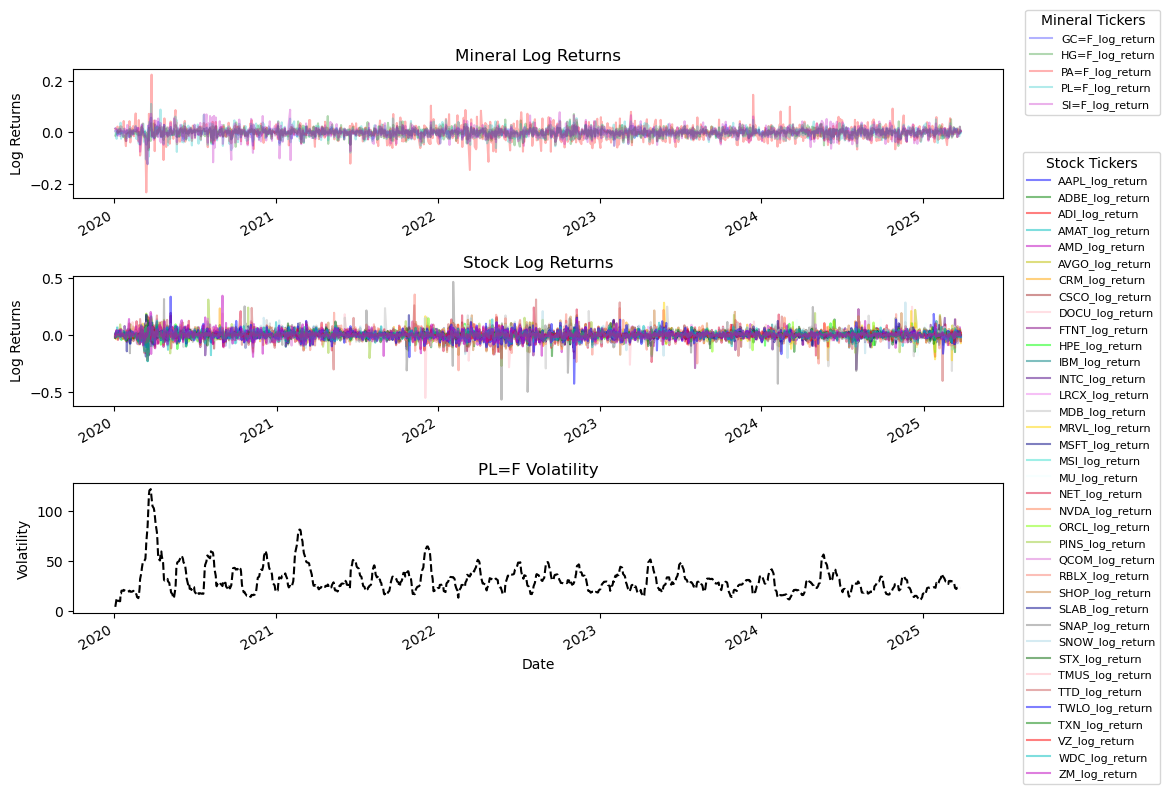

In [710]:
volatility_column = 'PL=F Close Volatility'

# Plotting the time series for minerals, stocks, and volatility
plt.figure(figsize=(14, 10))

# Plot mineral returns
plt.subplot(3, 1, 1)
minerals_log_return.set_index('Date').plot(figsize=(12, 8), ax=plt.gca(), title="Mineral Log Returns",alpha=0.3, color=['b', 'g', 'r', 'c', 'm', 'y'])
plt.legend(minerals_log_return_columns,title='Mineral Tickers', loc='upper right', bbox_to_anchor=(1.175, 1.5),fontsize=8)
plt.ylabel('Log Returns')
plt.xlabel('')

# Plot stock returns
plt.subplot(3, 1, 2)
stock_data_log_return.set_index('Date').plot(figsize=(12, 8), ax=plt.gca(),legend=False,alpha=0.5, title="Stock Log Returns",
                               color=['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'brown', 'pink', 'purple', 'lime', 'teal', 'indigo', 'violet',
                                      'silver', 'gold', 'navy', 'turquoise', 'azure', 'crimson', 'coral', 'chartreuse', 'yellowgreen', 'orchid',
                                      'salmon', 'peru', 'darkblue', 'gray', 'lightblue', 'darkgreen', 'lightpink', 'indianred'])
plt.legend(stock_log_return_columns,title='Stock Tickers', loc='upper right', bbox_to_anchor=(1.175, 2),fontsize=8)
plt.ylabel('Log Returns')
plt.xlabel('')

# Plot volatility
plt.subplot(3, 1, 3)
minerals_close_copy.set_index('Date')[volatility_column].plot(figsize=(12, 8), ax=plt.gca(), title="PL=F Volatility", color='black', linestyle='--')
plt.ylabel('Volatility')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.6)

plt.show()


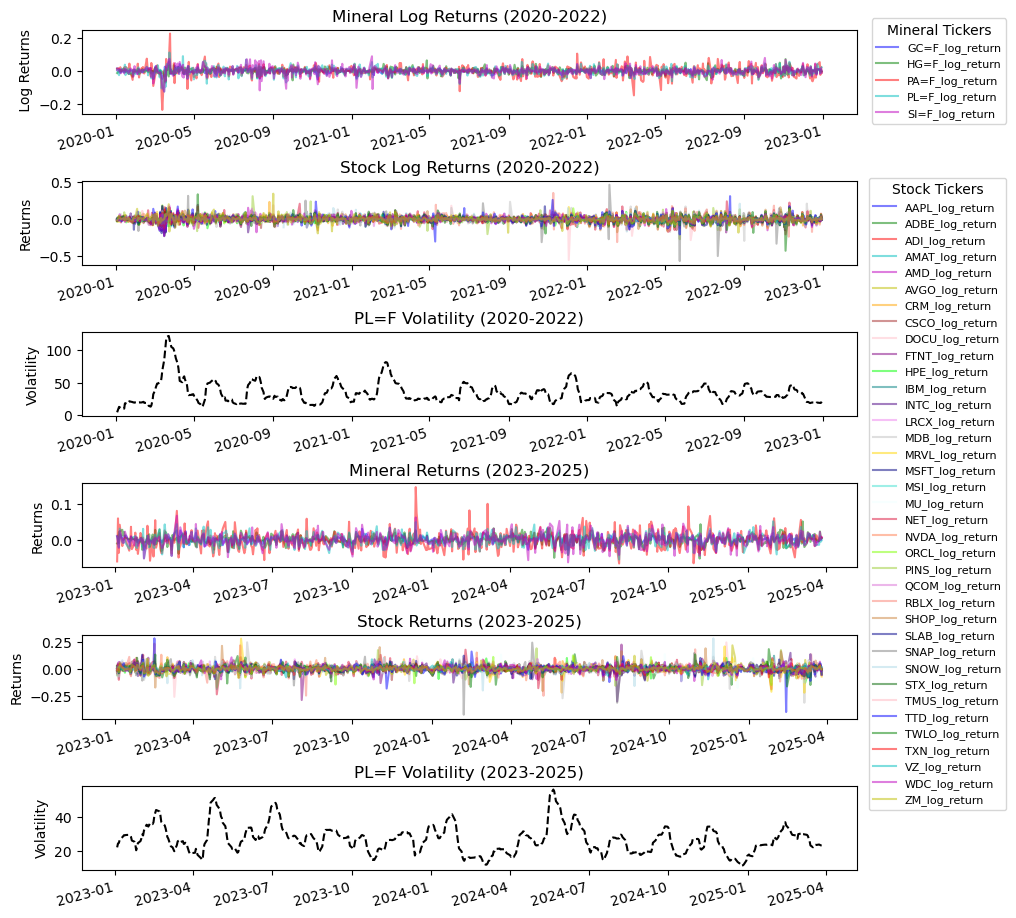

In [747]:

# Define the date ranges
start_date_1 = '2020-01-01'
end_date_1 = '2022-12-31'
start_date_2 = '2023-01-01'
end_date_2 = '2025-12-31'

# Filter data for the two periods
minerals_df_2020_2022 = minerals_log_return.set_index('Date').loc[start_date_1:end_date_1].copy()
minerals_df_2023_2025 = minerals_log_return.set_index('Date').loc[start_date_2:end_date_2].copy()

stock_df_2020_2022 = stock_data_log_return.loc[start_date_1:end_date_1].copy()
stock_df_2023_2025 = stock_data_log_return.loc[start_date_2:end_date_2].copy()

volatility_df_2020_2022 = minerals_close_copy.set_index('Date').filter(regex='Date|Vol').loc[start_date_1:end_date_1].copy()
volatility_df_2023_2025 = minerals_close_copy.set_index('Date').filter(regex='Date|Vol').loc[start_date_2:end_date_2].copy()

volatility_column = "PL=F Close Volatility"

# Plotting the time series for minerals, stocks, and volatility for 2020-2022
colors=['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'brown', 'pink', 'purple', 'lime', 'teal', 'indigo', 'violet', 'silver', 'gold', 'navy', 'turquoise', 'azure', 'crimson', 'coral', 'chartreuse', 'yellowgreen', 'orchid', 'salmon', 'peru', 'darkblue', 'gray', 'lightblue', 'darkgreen', 'lightpink']

# fig, axs = plt.subplots()
# plt.figure(figsize=(18, 7))

# Plot mineral returns (2020-2022)
axs1 = plt.subplot(6, 1, 1)
minerals_df_2020_2022[minerals_log_return_columns].plot(figsize=(12, 8), ax=axs1, title="Mineral Log Returns (2020-2022)", color=['b', 'g', 'r', 'c', 'm'],alpha=0.5)
plt.legend(minerals_log_return_columns,title='Mineral Tickers', loc='upper right', bbox_to_anchor=(1.2, 1.2),fontsize=8)
plt.xlabel('')
plt.ylabel(' Log Returns')
axs1.tick_params(axis='x', rotation=15)


# Plot stock returns (2020-2022)
axs2 = plt.subplot(6, 1, 2)
stock_df_2020_2022 [stock_log_return_columns].plot(figsize=(12, 8), ax=axs2, title="Stock Log Returns (2020-2022)", color=colors,alpha=0.5)
plt.legend(stock_log_return_columns,title='Stock Tickers', loc='upper right', bbox_to_anchor=(1.2, 1.1),fontsize=8)
plt.xlabel('')
plt.ylabel('Returns')
axs2.tick_params(axis='x', rotation=15)

# Plot volatility (2020-2022)
axs3 = plt.subplot(6, 1, 3)
volatility_df_2020_2022[volatility_column].plot(figsize=(10, 7), ax=axs3, title="PL=F Volatility (2020-2022)", color='black', linestyle='--')
plt.xlabel('')
plt.ylabel('Volatility')
axs3.tick_params(axis='x', rotation=15)

# Plotting the time series for minerals, stocks, and volatility for 2023-2025
# Plot mineral returns (2023-2025)
axs4 = plt.subplot(6, 1, 4)
minerals_df_2023_2025[minerals_log_return_columns].plot(figsize=(10, 7), ax=axs4, title="Mineral Returns (2023-2025)", color=['b', 'g', 'r', 'c', 'm', 'y'],legend=False,alpha=0.5)
plt.xlabel('')
plt.ylabel('Returns')
axs4.tick_params(axis='x', rotation=15)

# Plot stock returns (2023-2025)
axs5 = plt.subplot(6, 1, 5)
stock_df_2023_2025[stock_log_return_columns].plot(figsize=(10, 7), ax=axs5, title="Stock Returns (2023-2025)",color=colors,legend=False,alpha=0.5)
plt.xlabel('')
plt.ylabel('Returns')
axs5.tick_params(axis='x', rotation=15)

# Plot volatility (2023-2025)
axs6=plt.subplot(6, 1, 6)
volatility_df_2023_2025[volatility_column].plot(figsize=(10, 7), ax=axs6, title="PL=F Volatility (2023-2025)", color='black', linestyle='--',legend=False)
plt.ylabel('Volatility')
plt.xlabel('')
axs6.tick_params(axis='x', rotation=15)

plt.subplots_adjust(left=None, right=None, 
                    top=1.7, bottom=.5, 
                    wspace=0.4, hspace=0.8)

plt.show()


In [763]:
# Define lag range (1-10)
lags = range(1, 11)

# Function to create lagged features for minerals
def create_lagged_df(df, columns, lags):
    lagged_dfs = []
    for lag in lags:
        lagged_dfs.append(df[columns].shift(lag).add_suffix(f'_lag_{lag}'))
    return pd.concat(lagged_dfs, axis=1)

# Create lagged columns for the minerals
lagged_minerals_df = create_lagged_df(minerals_log_return.set_index('Date'), minerals_log_return_columns, lags)
lagged_stock_df = create_lagged_df(stock_data_log_return, stock_log_return_columns, lags)

In [713]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf, pacf, acf

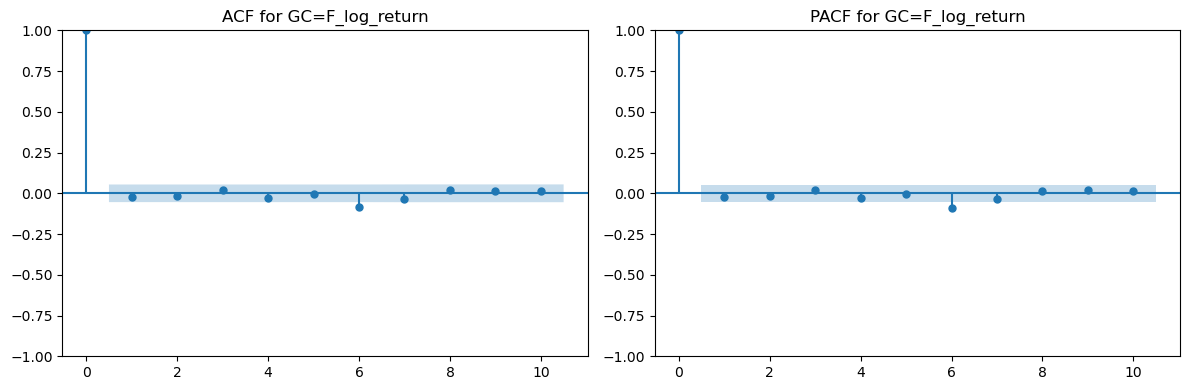

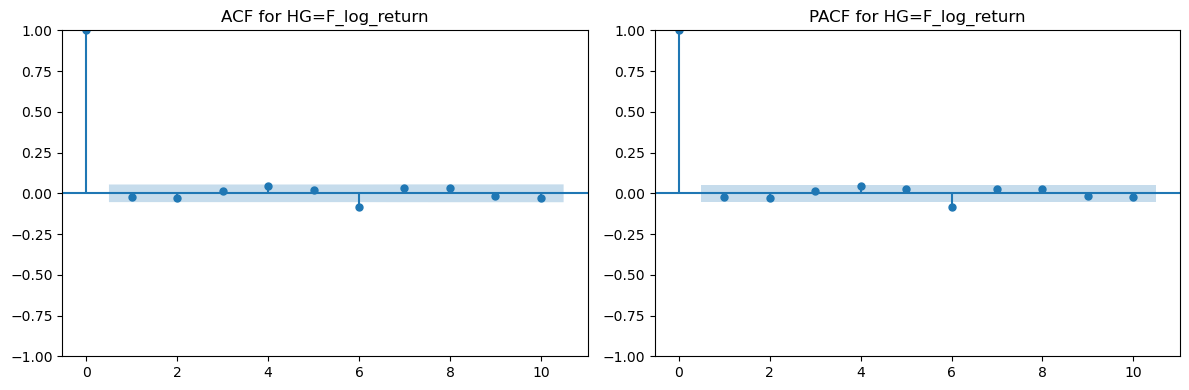

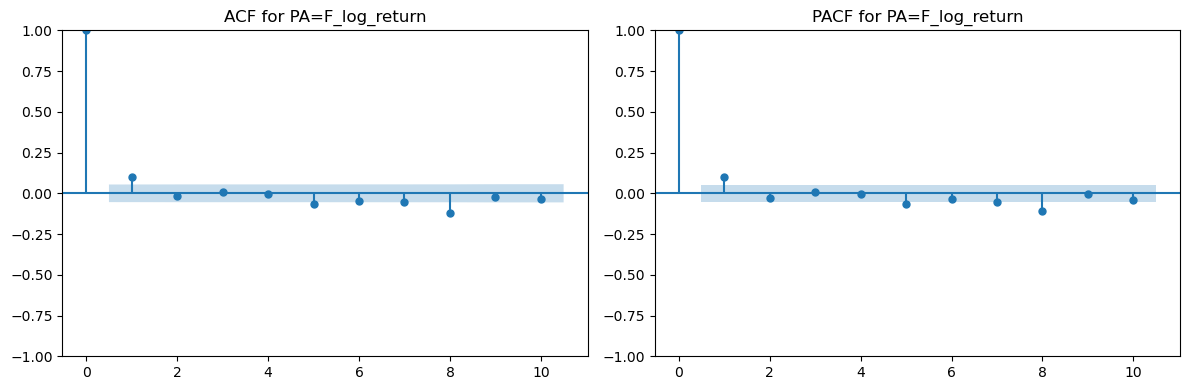

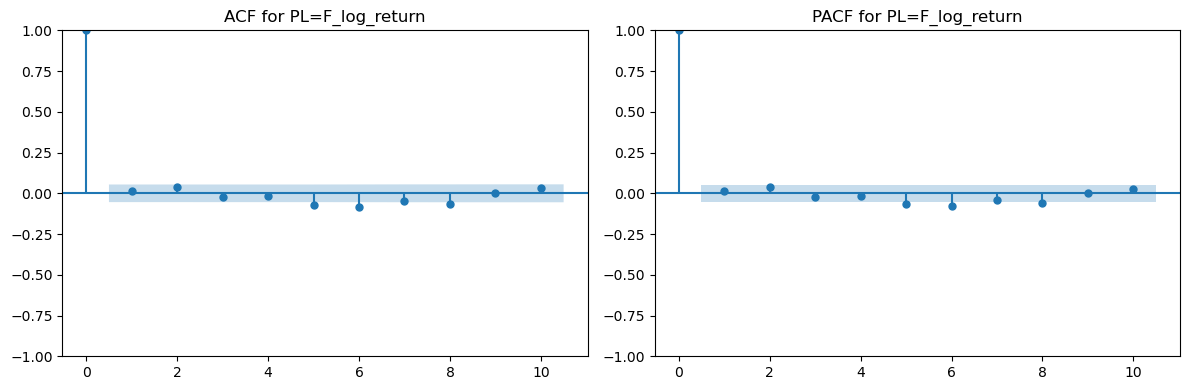

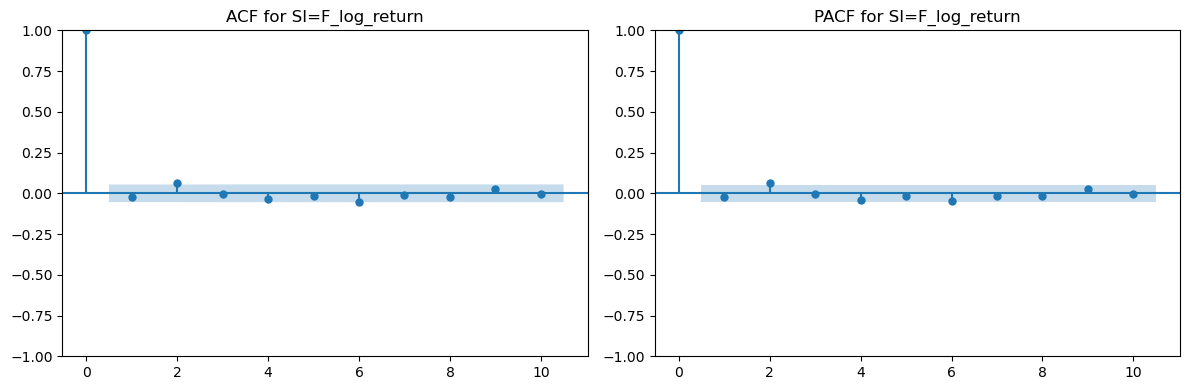

In [714]:
# Loop through each mineral column and plot ACF/PACF directly
for mineral in minerals_log_return_columns:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    sm.graphics.tsa.plot_acf(minerals_log_return[mineral].dropna(), lags=10, ax=axs[0])
    axs[0].set_title(f'ACF for {mineral}')
    
    sm.graphics.tsa.plot_pacf(minerals_log_return[mineral].dropna(), lags=10, ax=axs[1])
    axs[1].set_title(f'PACF for {mineral}')
    
    plt.tight_layout()
    plt.show()


### Top correlations between mineral lagged log returns and stock log Return

In [766]:
# Prepare an empty DataFrame to store the ACF/PACF results
correlation_results = {}


# Loop over each lagged mineral column (in lagged_minerals_df) and each stock column to compute ACF and PACF
for mineral_col in lagged_minerals_df.columns:  # Using columns in lagged_minerals_df
    for stock_col in stock_log_return_columns:
        # Drop NaN values from both series to ensure proper alignment
        mineral_series = lagged_minerals_df[mineral_col].dropna()  # Get the lagged series
        stock_series = stock_data_log_return[stock_col].dropna()  # Get the stock log returns
        
        # Ensure the series are aligned by their indices
        aligned_data = pd.concat([mineral_series, stock_series], axis=1).dropna()
        mineral_series = aligned_data[mineral_col]
        stock_series = aligned_data[stock_col]
        
        # Calculate ACF and PACF between lagged mineral and stock returns
        lag_correlation = np.corrcoef(mineral_series, stock_series)[:1,1][0]
        
        # Store the results
        correlation_results[f'{mineral_col} vs {stock_col}'] = lag_correlation
       

top_corr = sorted(correlation_results.items(), key=lambda x: abs(x[1]), reverse=True)[:20]

top_corr


[('PL=F_log_return_lag_2 vs TMUS_log_return', 0.1346452938171628),
 ('PL=F_log_return_lag_2 vs PINS_log_return', 0.11148263115843561),
 ('PL=F_log_return_lag_4 vs FTNT_log_return', -0.10942654146151082),
 ('PL=F_log_return_lag_9 vs INTC_log_return', 0.10756222292150835),
 ('PL=F_log_return_lag_2 vs MSI_log_return', 0.10480503819575183),
 ('PL=F_log_return_lag_2 vs VZ_log_return', 0.10368359744153886),
 ('GC=F_log_return_lag_7 vs WDC_log_return', -0.09677603291634312),
 ('PL=F_log_return_lag_2 vs LRCX_log_return', 0.0966100221420461),
 ('PL=F_log_return_lag_2 vs AMD_log_return', 0.09568973463048518),
 ('PL=F_log_return_lag_2 vs SNAP_log_return', 0.0928220363350643),
 ('PL=F_log_return_lag_6 vs IBM_log_return', -0.09231431622258551),
 ('PL=F_log_return_lag_2 vs AMAT_log_return', 0.09222792347651709),
 ('PL=F_log_return_lag_2 vs ADI_log_return', 0.09210151620413354),
 ('HG=F_log_return_lag_1 vs PINS_log_return', -0.09037390553287943),
 ('PA=F_log_return_lag_5 vs TTD_log_return', -0.090143

### Top correlations between mineral lagged log returns and stock lagged log returns

In [768]:
# Prepare an empty DataFrame to store the ACF/PACF results
correlation_results = {}


# Loop over each lagged mineral column (in lagged_minerals_df) and each stock column to compute ACF and PACF
for mineral_col in lagged_minerals_df.columns:  # Using columns in lagged_minerals_df
    for stock_col in lagged_stock_df.columns:
        # Drop NaN values from both series to ensure proper alignment
        mineral_series = lagged_minerals_df[mineral_col].dropna()  # Get the lagged series
        stock_series = lagged_stock_df[stock_col].dropna()  # Get the stock log returns
        
        # Ensure the series are aligned by their indices
        aligned_data = pd.concat([mineral_series, stock_series], axis=1).dropna()
        mineral_series = aligned_data[mineral_col]
        stock_series = aligned_data[stock_col]
        
        # Calculate ACF and PACF between lagged mineral and stock returns
        lag_correlation = np.corrcoef(mineral_series, stock_series)[:1,1][0]
        
        # Store the results
        correlation_results[f'{mineral_col} vs {stock_col}'] = lag_correlation
       

top_corr = sorted(correlation_results.items(), key=lambda x: abs(x[1]), reverse=True)[:20]

top_corr


[('HG=F_log_return_lag_10 vs WDC_log_return_lag_10', 0.26690613394270535),
 ('HG=F_log_return_lag_9 vs WDC_log_return_lag_9', 0.26618966088952),
 ('HG=F_log_return_lag_8 vs WDC_log_return_lag_8', 0.2652001654798334),
 ('HG=F_log_return_lag_7 vs WDC_log_return_lag_7', 0.2651868445633261),
 ('HG=F_log_return_lag_5 vs WDC_log_return_lag_5', 0.2648207557428144),
 ('HG=F_log_return_lag_6 vs WDC_log_return_lag_6', 0.2647267714017634),
 ('HG=F_log_return_lag_4 vs WDC_log_return_lag_4', 0.2641264729009259),
 ('HG=F_log_return_lag_2 vs WDC_log_return_lag_2', 0.2639203493716049),
 ('HG=F_log_return_lag_3 vs WDC_log_return_lag_3', 0.26371054900524793),
 ('HG=F_log_return_lag_1 vs WDC_log_return_lag_1', 0.26309945185534395),
 ('PL=F_log_return_lag_3 vs ADI_log_return_lag_3', 0.25508960217919086),
 ('PL=F_log_return_lag_3 vs WDC_log_return_lag_3', 0.2548672307669243),
 ('PL=F_log_return_lag_4 vs ADI_log_return_lag_4', 0.25410827326374896),
 ('PL=F_log_return_lag_6 vs WDC_log_return_lag_6', 0.253899

In [ ]:
# Create lagged volume and volatility columns up to 5 lags
lags = 5
lagged_volatility_columns = ['PL=F Close Volatility']
lagged_volume_columns = [
    'GC=F Volume', 'HG=F Volume', 'PA=F Volume', 'PL=F Volume', 'SI=F Volume', 'SLAB Volume'
]

# Create a DataFrame to hold lagged values
lagged_volume_df = pd.DataFrame()

# Create lagged volumes
for col in lagged_volume_columns:
    for lag in range(1, lags + 1):
        lagged_volume_df[f'{col}_lag_{lag}'] = metals[col].shift(lag)

# Create lagged volatility
for lag in range(1, lags + 1):
    lagged_volume_df[f'PL=F Volatility_lag_{lag}'] = master_df1['PL=F Close Volatility'].shift(lag)

# Display the first few rows of the DataFrame to ensure the lagged columns are correctly created
lagged_volume_df.head()


,GC=F Volume_lag_1,GC=F Volume_lag_2,GC=F Volume_lag_3,GC=F Volume_lag_4,GC=F Volume_lag_5,HG=F Volume_lag_1,HG=F Volume_lag_2,HG=F Volume_lag_3,HG=F Volume_lag_4,HG=F Volume_lag_5,...,SLAB Volume_lag_1,SLAB Volume_lag_2,SLAB Volume_lag_3,SLAB Volume_lag_4,SLAB Volume_lag_5,PL=F Volatility_lag_1,PL=F Volatility_lag_2,PL=F Volatility_lag_3,PL=F Volatility_lag_4,PL=F Volatility_lag_5
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,214.0,NaN,NaN,NaN,NaN,1182.0,NaN,NaN,NaN,NaN,...,162600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,107.0,214.0,NaN,NaN,NaN,321.0,1182.0,NaN,NaN,NaN,...,157100.0,162600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,416.0,107.0,214.0,NaN,NaN,333.0,321.0,1182.0,NaN,NaN,...,232900.0,157100.0,162600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,47.0,416.0,107.0,214.0,NaN,261.0,333.0,321.0,1182.0,NaN,...,147900.0,232900.0,157100.0,162600.0,NaN,NaN,NaN,NaN,NaN,NaN


In [719]:
# Function to calculate ACF and PACF for a single series
def calculate_acf_pacf(x, lags=8):
    x_values = x.values.flatten() 
    lags = int(lags)
    
    # Calculate ACF and PACF using numpy arrays
    acf_vals = acf(x_values, nlags=lags, adjusted=True)  # Only use adjusted (no fft)
    pacf_vals = pacf(x_values, nlags=lags)  # Removed adjusted argument as it is not accepted now
    
    return acf_vals, pacf_vals

# Now calculate ACF and PACF for each interaction term with stock returns
acf_results = {}
pacf_results = {}


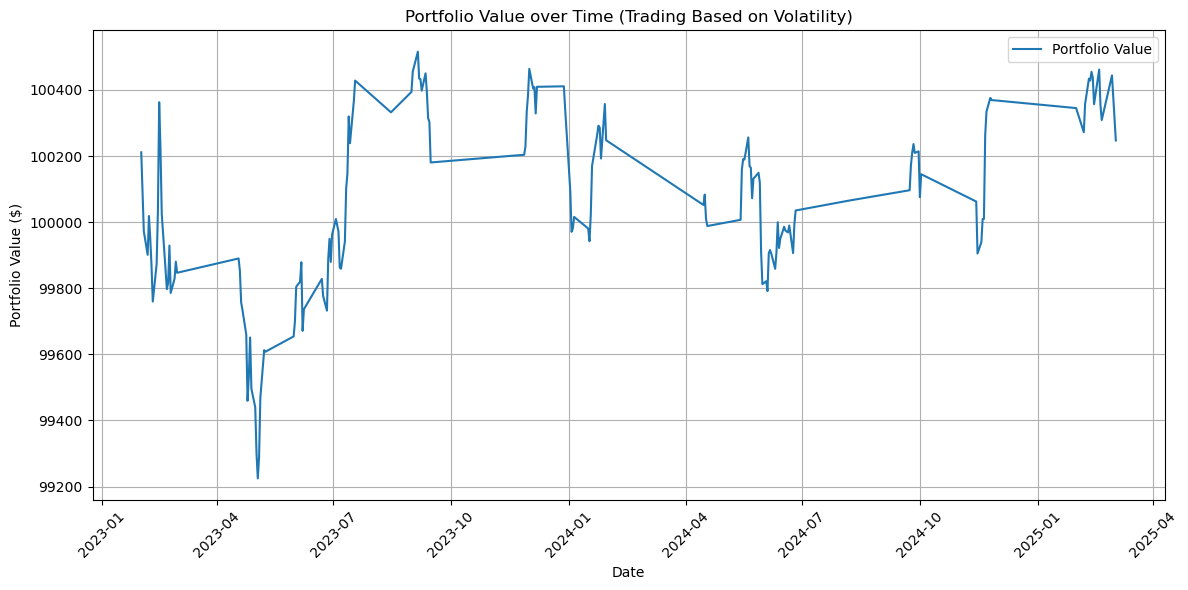

In [720]:
# Initialize parameters for the strategy
volatility_threshold_pct = 0.7  # Top 30% volatility for trading
max_investment_pct = 0.06  

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns


max_investment = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Close Volatility']
    if np.isnan(volatility):
        continue
  
    if volatility < np.percentile(test_data['PL=F Close Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade
    total_investment = min(portfolio_value, max_investment_pct * portfolio_value)  # Ensure not exceeding total portfolio

    # Investment per stock (split the total investment evenly)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        if pd.isna(row[stock]):
            continue

        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Update portfolio based on the return for this stock (assuming buying)
        portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
        portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
        
        trade_history.append({
            'date': row.name,
            'action': 'Buy',
            'stock': stock,
            'investment': investment_per_stock,
            'portfolio_value': portfolio_value,
            'return_pct': stock_return * 100,
            'gain_loss': investment_per_stock * stock_return

        })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

# Plot the cumulative returns over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value over Time (Trading Based on Volatility)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()  # Adjust the layout to fit labels
plt.show()


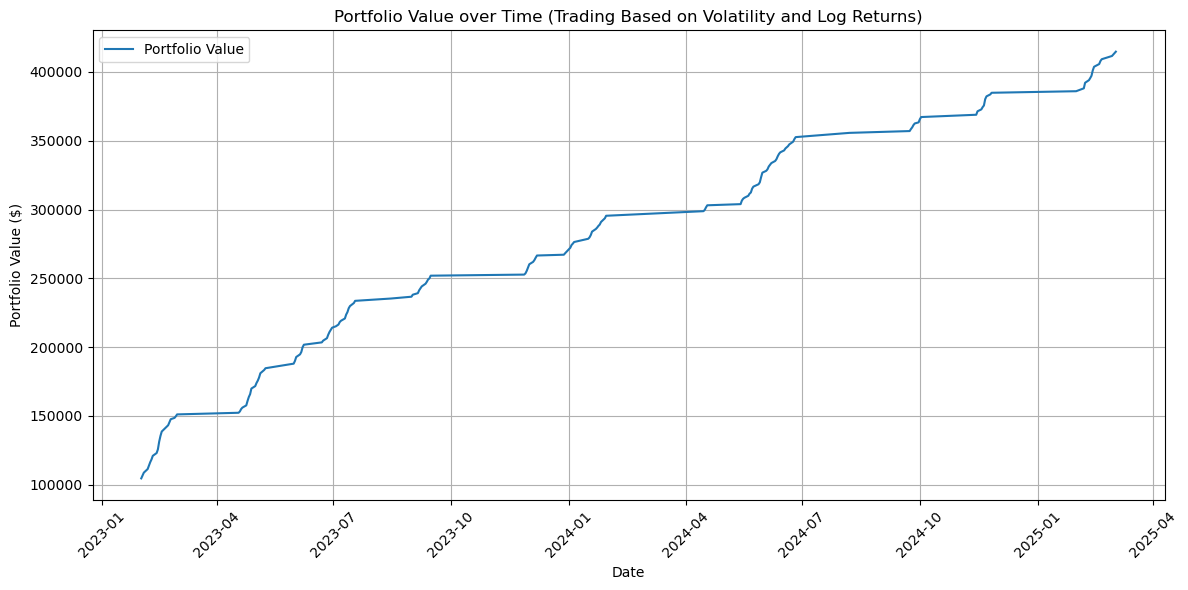

In [721]:

# Initialize parameters for the strategy
volatility_threshold_pct = 0.7  # Top 30% volatility for trading
max_investment_pct = 0.06  # Max 6% of portfolio per stock

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns


max_investment = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Close Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['PL=F Close Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade
    total_investment = min(portfolio_value, max_investment * len(stocks_to_buy))  # Ensure not exceeding total portfolio

    # Investment per stock (split the total investment evenly)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

# Plot the cumulative returns over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value over Time (Trading Based on Volatility and Log Returns)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()  # Adjust the layout to fit labels
plt.show()


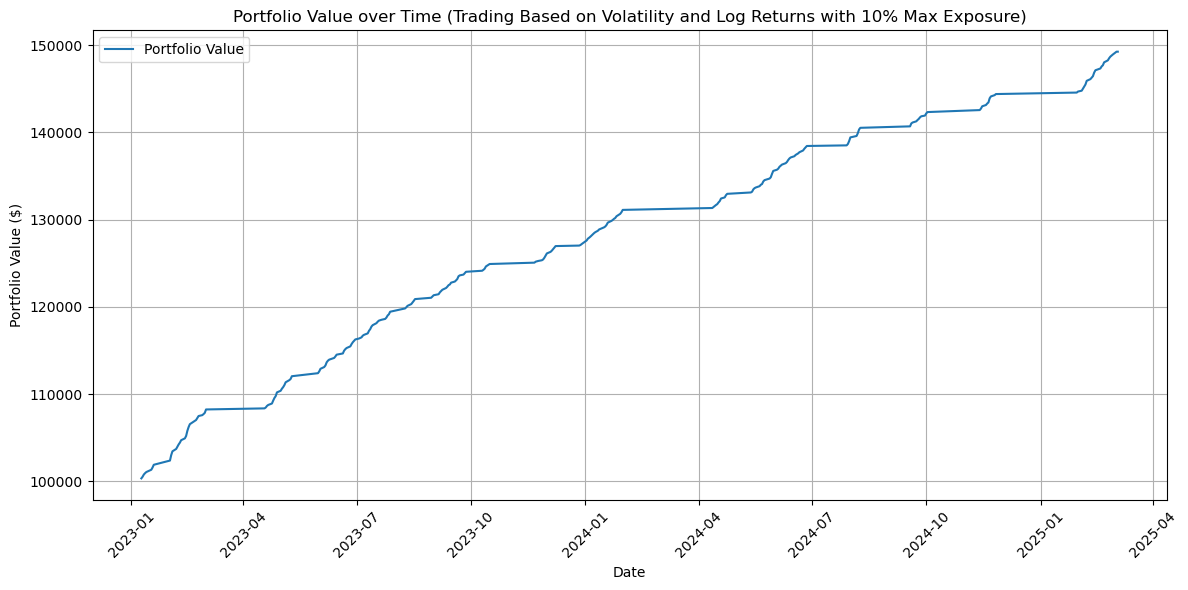

In [722]:


# Initialize parameters for the strategy
volatility_threshold_pct = 0.55  # Top 30% volatility for trading
max_investment_pct = 0.1  # Total max exposure per day is 10% of the portfolio

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns

# Calculate max exposure per day (10% of portfolio)
max_daily_exposure = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Close Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['PL=F Close Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade (max 10% of portfolio)
    total_investment = min(portfolio_value, max_daily_exposure)  # Ensure not exceeding the 10% daily exposure

    # Investment per stock (split the total investment evenly across all selected stocks)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

# Plot the cumulative returns over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value over Time (Trading Based on Volatility and Log Returns with 10% Max Exposure)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()  # Adjust the layout to fit labels
plt.show()


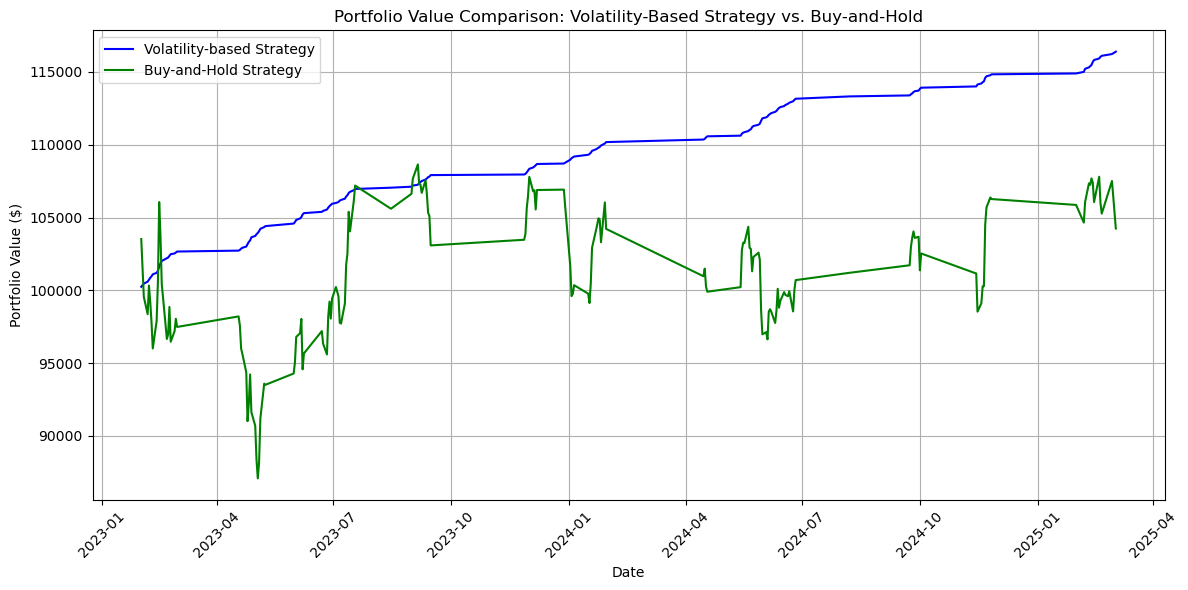

Volatility-Based Strategy Volatility: 0.0004
Buy-and-Hold Strategy Volatility: 0.0161
Volatility-Based Strategy Sharpe Ratio: 2.1528
Buy-and-Hold Strategy Sharpe Ratio: 0.0027


In [723]:
# Initialize parameters for the strategy
volatility_threshold_pct = 0.7  # Top 30% volatility for trading
max_investment_pct = 0.05  # Total max exposure per day is 10% of the portfolio

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns
buy_and_hold_value = initial_balance
buy_and_hold_cumulative_returns = []  # Track buy and hold cumulative returns

# Calculate max exposure per day (10% of portfolio)
max_daily_exposure = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Close Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['PL=F Close Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade (max 10% of portfolio)
    total_investment = min(portfolio_value, max_daily_exposure)  # Ensure not exceeding the 10% daily exposure

    # Investment per stock (split the total investment evenly across all selected stocks)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

    # Buy-and-Hold Strategy (equally invest in each stock at the start and hold)
    buy_and_hold_investment_per_stock = initial_balance / len(stocks_to_buy)
    
    for stock in stocks_to_buy:
        stock_return = np.exp(row[stock]) - 1
        buy_and_hold_value += buy_and_hold_investment_per_stock * stock_return
    
    # Store the buy-and-hold portfolio value for comparison
    buy_and_hold_cumulative_returns.append(buy_and_hold_value)

# Convert portfolio date for proper alignment
portfolio_dates = pd.to_datetime(portfolio_dates)

# Calculate the cumulative returns for both strategies
cumulative_returns = np.array(cumulative_returns)
buy_and_hold_cumulative_returns = np.array(buy_and_hold_cumulative_returns)

# Plot the cumulative returns of both strategies
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Volatility-based Strategy", color="blue")
plt.plot(portfolio_dates, buy_and_hold_cumulative_returns, label="Buy-and-Hold Strategy", color="green")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value Comparison: Volatility-Based Strategy vs. Buy-and-Hold")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate volatility for both strategies
volatility_volatility_based = np.std(np.diff(np.log(cumulative_returns)))
volatility_buy_and_hold = np.std(np.diff(np.log(buy_and_hold_cumulative_returns)))

# Calculate Sharpe Ratios (assume risk-free rate of 0)
mean_return_volatility_based = np.mean(np.diff(np.log(cumulative_returns)))
mean_return_buy_and_hold = np.mean(np.diff(np.log(buy_and_hold_cumulative_returns)))

sharpe_ratio_volatility_based = mean_return_volatility_based / volatility_volatility_based
sharpe_ratio_buy_and_hold = mean_return_buy_and_hold / volatility_buy_and_hold

print(f"Volatility-Based Strategy Volatility: {volatility_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Volatility: {volatility_buy_and_hold:.4f}")
print(f"Volatility-Based Strategy Sharpe Ratio: {sharpe_ratio_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Sharpe Ratio: {sharpe_ratio_buy_and_hold:.4f}")


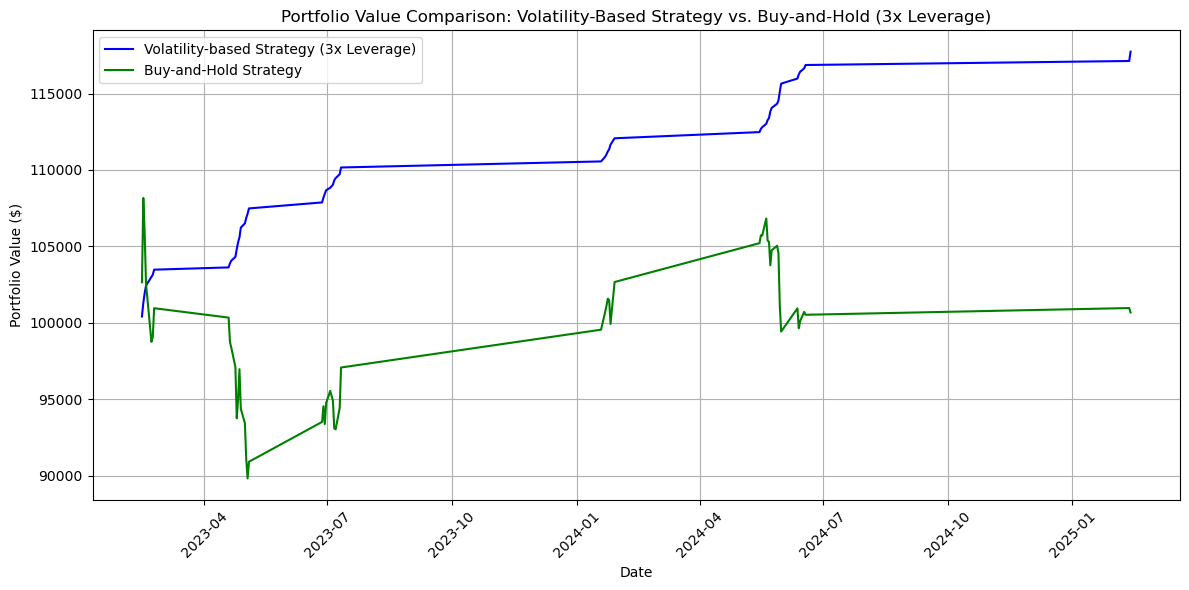

Volatility-Based Strategy Volatility (3x Leverage): 0.0015
Buy-and-Hold Strategy Volatility: 0.0182
Volatility-Based Strategy Sharpe Ratio (3x Leverage): 1.9332
Buy-and-Hold Strategy Sharpe Ratio: -0.0198


In [724]:
# Initialize parameters for the strategy
volatility_threshold_pct = 0.9  # Top 30% volatility for trading
max_investment_pct = 0.05  # Total max exposure per day is 5% of the portfolio
leverage_factor = 3  # 3x leverage

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns
buy_and_hold_value = initial_balance
buy_and_hold_cumulative_returns = []  # Track buy and hold cumulative returns

# Calculate max exposure per day (5% of portfolio)
max_daily_exposure = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Close Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['PL=F Close Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade (max 5% of portfolio, with leverage)
    total_investment = min(portfolio_value, max_daily_exposure)  # Ensure not exceeding the 5% daily exposure
    total_investment_with_leverage = total_investment * leverage_factor  # Apply 3x leverage

    # Investment per stock (split the total investment evenly across all selected stocks)
    investment_per_stock = total_investment_with_leverage / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

    # Buy-and-Hold Strategy (equally invest in each stock at the start and hold)
    buy_and_hold_investment_per_stock = initial_balance / len(stocks_to_buy)
    
    for stock in stocks_to_buy:
        stock_return = np.exp(row[stock]) - 1
        buy_and_hold_value += buy_and_hold_investment_per_stock * stock_return
    
    # Store the buy-and-hold portfolio value for comparison
    buy_and_hold_cumulative_returns.append(buy_and_hold_value)

# Convert portfolio date for proper alignment
portfolio_dates = pd.to_datetime(portfolio_dates)

# Calculate the cumulative returns for both strategies
cumulative_returns = np.array(cumulative_returns)
buy_and_hold_cumulative_returns = np.array(buy_and_hold_cumulative_returns)

# Plot the cumulative returns of both strategies
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Volatility-based Strategy (3x Leverage)", color="blue")
plt.plot(portfolio_dates, buy_and_hold_cumulative_returns, label="Buy-and-Hold Strategy", color="green")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value Comparison: Volatility-Based Strategy vs. Buy-and-Hold (3x Leverage)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate volatility for both strategies
volatility_volatility_based = np.std(np.diff(np.log(cumulative_returns)))
volatility_buy_and_hold = np.std(np.diff(np.log(buy_and_hold_cumulative_returns)))

# Calculate Sharpe Ratios (assume risk-free rate of 0)
mean_return_volatility_based = np.mean(np.diff(np.log(cumulative_returns)))
mean_return_buy_and_hold = np.mean(np.diff(np.log(buy_and_hold_cumulative_returns)))

sharpe_ratio_volatility_based = mean_return_volatility_based / volatility_volatility_based
sharpe_ratio_buy_and_hold = mean_return_buy_and_hold / volatility_buy_and_hold

print(f"Volatility-Based Strategy Volatility (3x Leverage): {volatility_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Volatility: {volatility_buy_and_hold:.4f}")
print(f"Volatility-Based Strategy Sharpe Ratio (3x Leverage): {sharpe_ratio_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Sharpe Ratio: {sharpe_ratio_buy_and_hold:.4f}")


In [725]:
def maxProfitUtil(i, k, buy, prices):

    # Base case: no transactions or end of list
    if k <= 0 or i >= len(prices):
        return 0

    result = 0
    profit = 0

    
    if buy:
      
        
        profit = maxProfitUtil(i + 1, k, 0, 
                               prices) - prices[i]
        result = max(result, profit)
    else:
      
        profit = prices[i] + maxProfitUtil(i + 1,
                                  k - 1,1, prices)
        result = max(result, profit)

    # Skip current price
    profit = maxProfitUtil(i + 1, k, buy, prices)
    return max(result, profit)

# Function to return max profit with k transactions
def maxProfit(prices, k):
  
    # Start from first price in 'buy' state
    return maxProfitUtil(0, k, 1, prices)

if __name__ == "__main__":
    k = 3
    prices = [1, 2, 3, 2, 1, 1, 2, 4, 8, 2]
    print(maxProfit(prices, k))



9
